In [1]:
# ==============================================================================
# 1. ENVIRONMENT SETUP & LIBRARIES
# ==============================================================================
import os
import glob
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# Define dataset directory path
DATA_DIR = "/kaggle/input/datasets/prosenjitmondol/metabonet"

# Verify files present in the directory
available_files = glob.glob(os.path.join(DATA_DIR, "*.parquet"))
print("Found Parquet files:")
for f in available_files:
    print(f" - {os.path.basename(f)} ({os.path.getsize(f) / (1024 * 1024):.2f} MB)")

Found Parquet files:
 - annual_competition_secret_holdout_set_public.parquet (22.66 MB)
 - train.parquet (1103.95 MB)
 - test.parquet (249.78 MB)


In [8]:
import polars as pl

train_path = "/kaggle/input/datasets/prosenjitmondol/metabonet/train.parquet"
lazy_df = pl.scan_parquet(train_path)

# Compute non-null counts across the entire 132M dataset efficiently
null_analysis = lazy_df.select([
    (pl.col(c).is_not_null().sum() / pl.len() * 100).alias(c)
    for c in lazy_df.collect_schema().names()
]).collect(engine="streaming")

# Display sorted presence percentage
presence_df = (
    null_analysis.to_pandas().T
    .rename(columns={0: "valid_data_percentage"})
    .sort_values(by="valid_data_percentage", ascending=False)
)

print(presence_df)

                                valid_data_percentage
subject_split_across_traintest             100.000000
is_test                                    100.000000
source_file                                100.000000
id                                         100.000000
date                                       100.000000
age                                         99.856171
insulin_delivery_modality                   99.123016
insulin_delivery_algorithm                  97.594517
insulin_delivery_device                     95.205889
cgm_device                                  94.935287
age_of_diagnosis                            94.259070
weight                                      94.239460
height                                      94.048535
ethnicity                                   93.963672
insulin_type_basal                          92.698976
insulin_type_bolus                          92.195956
insulin                                     90.402253
bolus                       

In [6]:
# ==============================================================================
# 2. MEMORY-EFFICIENT DATA LOADING & SCHEMA INSPECTION
# ==============================================================================
import os
import polars as pl

DATA_DIR = "/kaggle/input/datasets/prosenjitmondol/metabonet"
train_path = os.path.join(DATA_DIR, "train.parquet")
test_path = os.path.join(DATA_DIR, "test.parquet")

# 1. Inspect Schema
lazy_train = pl.scan_parquet(train_path)
print("Schema of train.parquet:")
print(lazy_train.collect_schema())

# 2. Define essential columns to load
essential_cols = [
    "id", "date", "CGM", "basal", "bolus", "insulin", "carbs",
    "heartrate", "steps", "age", "gender", "weight", "height", "age_of_diagnosis"
]

available_cols = [col for col in essential_cols if col in lazy_train.collect_schema().names()]

# 3. Load train set
df_train = (
    lazy_train
    .select(available_cols)
    .with_columns(pl.col(pl.Float64).cast(pl.Float32))
    .collect(engine="streaming")
)
print(f"\nTrain set loaded: {df_train.shape[0]:,} rows, {df_train.shape[1]} columns")
print(f"RAM usage (train): {df_train.estimated_size() / (1024**2):.2f} MB")

# 4. Load test set
if os.path.exists(test_path):
    lazy_test = pl.scan_parquet(test_path)
    test_avail_cols = [col for col in essential_cols if col in lazy_test.collect_schema().names()]
    
    df_test = (
        lazy_test
        .select(test_avail_cols)
        .with_columns(pl.col(pl.Float64).cast(pl.Float32))
        .collect(engine="streaming")
    )
    print(f"Test set loaded:  {df_test.shape[0]:,} rows, {df_test.shape[1]} columns")
    print(f"RAM usage (test):  {df_test.estimated_size() / (1024**2):.2f} MB")

# 5. Display top 10 rows where key metabolic values are present
df_sample = (
    lazy_train
    .select(available_cols)
    .filter(
        pl.col("CGM").is_not_null() &
        pl.col("insulin").is_not_null() &
        pl.col("carbs").is_not_null()
    )
    .head(10)
    .collect()
)

print("\nTop 10 rows with populated values:")
print(df_sample)

Schema of train.parquet:
Schema({'CGM': Float64, 'age': Float64, 'air_temp': Float64, 'basal': Float64, 'bolus': Float64, 'calories_burned': Float64, 'carbs': Float64, 'cgm_device': String, 'misc_notes': String, 'date': Datetime(time_unit='ns', time_zone=None), 'galvanic_skin_response': Float64, 'heartrate': Float64, 'height': Float64, 'id': String, 'insulin': Float64, 'insulin_delivery_algorithm': String, 'insulin_delivery_device': String, 'insulin_delivery_modality': String, 'insulin_type_basal': String, 'insulin_type_bolus': String, 'is_pregnant': Boolean, 'is_test': Boolean, 'meal_label': String, 'skin_temp': Float64, 'source_file': String, 'steps': Float64, 'weight': Float64, 'workout_duration': Float64, 'workout_intensity': Float64, 'workout_label': String, 'treatment_group': String, 'randomization_date': Datetime(time_unit='ns', time_zone=None), 'extension_date': Datetime(time_unit='ns', time_zone=None), 'gender': String, 'age_of_diagnosis': Float64, 'ethnicity': String, 'subjec

In [ ]:
import polars as pl

# 1. Expand Polars output display to see all 37 columns and full widths
pl.Config.set_tbl_cols(40)
pl.Config.set_tbl_rows(10)
pl.Config.set_tbl_width_chars(300)

train_path = "/kaggle/input/datasets/prosenjitmondol/metabonet/train.parquet"

# 2. Filter for rows where CGM, insulin/carbs, and key metrics are populated
valid_sample = (
    pl.scan_parquet(train_path)
    .filter(
        pl.col("CGM").is_not_null() & 
        (pl.col("insulin").is_not_null() | pl.col("carbs").is_not_null())
    )
    .head(5)
    .collect()
)

valid_sample

Feature Completion Summary:
                  null_count  completion_rate (%)
id                         0           100.000000
date                       0           100.000000
age                   190966            99.856171
age_of_diagnosis     7622378            94.259070
weight               7648415            94.239460
height               7901910            94.048535
insulin             12743172            90.402253
bolus               15227205            88.531359
basal               16392263            87.653875
gender              19826321            85.067452
CGM                 21459883            83.837106
carbs               44714406            66.322547
heartrate          131902898             0.654978
steps              131967330             0.606450


/tmp/ipykernel_268/158898354.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=null_summary.index, y=null_summary["completion_rate (%)"], palette="viridis")


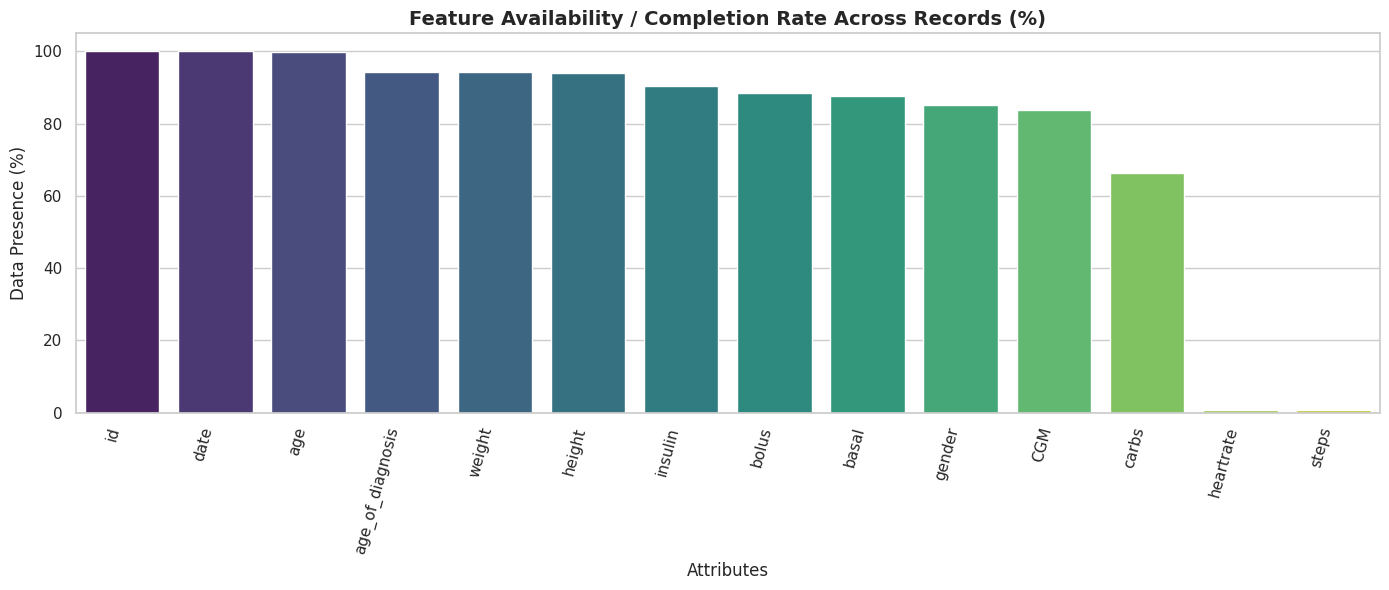

In [3]:
# ==============================================================================
# 3. MISSING VALUE & FEATURE COMPLETION PROFILE
# ==============================================================================
# Convert to pandas for aggregate visualization
null_summary = df_train.null_count().to_pandas().T
null_summary.columns = ["null_count"]
null_summary["completion_rate (%)"] = 100 * (1 - (null_summary["null_count"] / len(df_train)))
null_summary = null_summary.sort_values(by="completion_rate (%)", ascending=False)

print("Feature Completion Summary:")
print(null_summary)

plt.figure(figsize=(14, 6))
sns.barplot(x=null_summary.index, y=null_summary["completion_rate (%)"], palette="viridis")
plt.xticks(rotation=75, ha="right")
plt.title("Feature Availability / Completion Rate Across Records (%)", fontsize=14, fontweight="bold")
plt.ylabel("Data Presence (%)")
plt.xlabel("Attributes")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

Total Unique Subjects in Training Set: 1,183


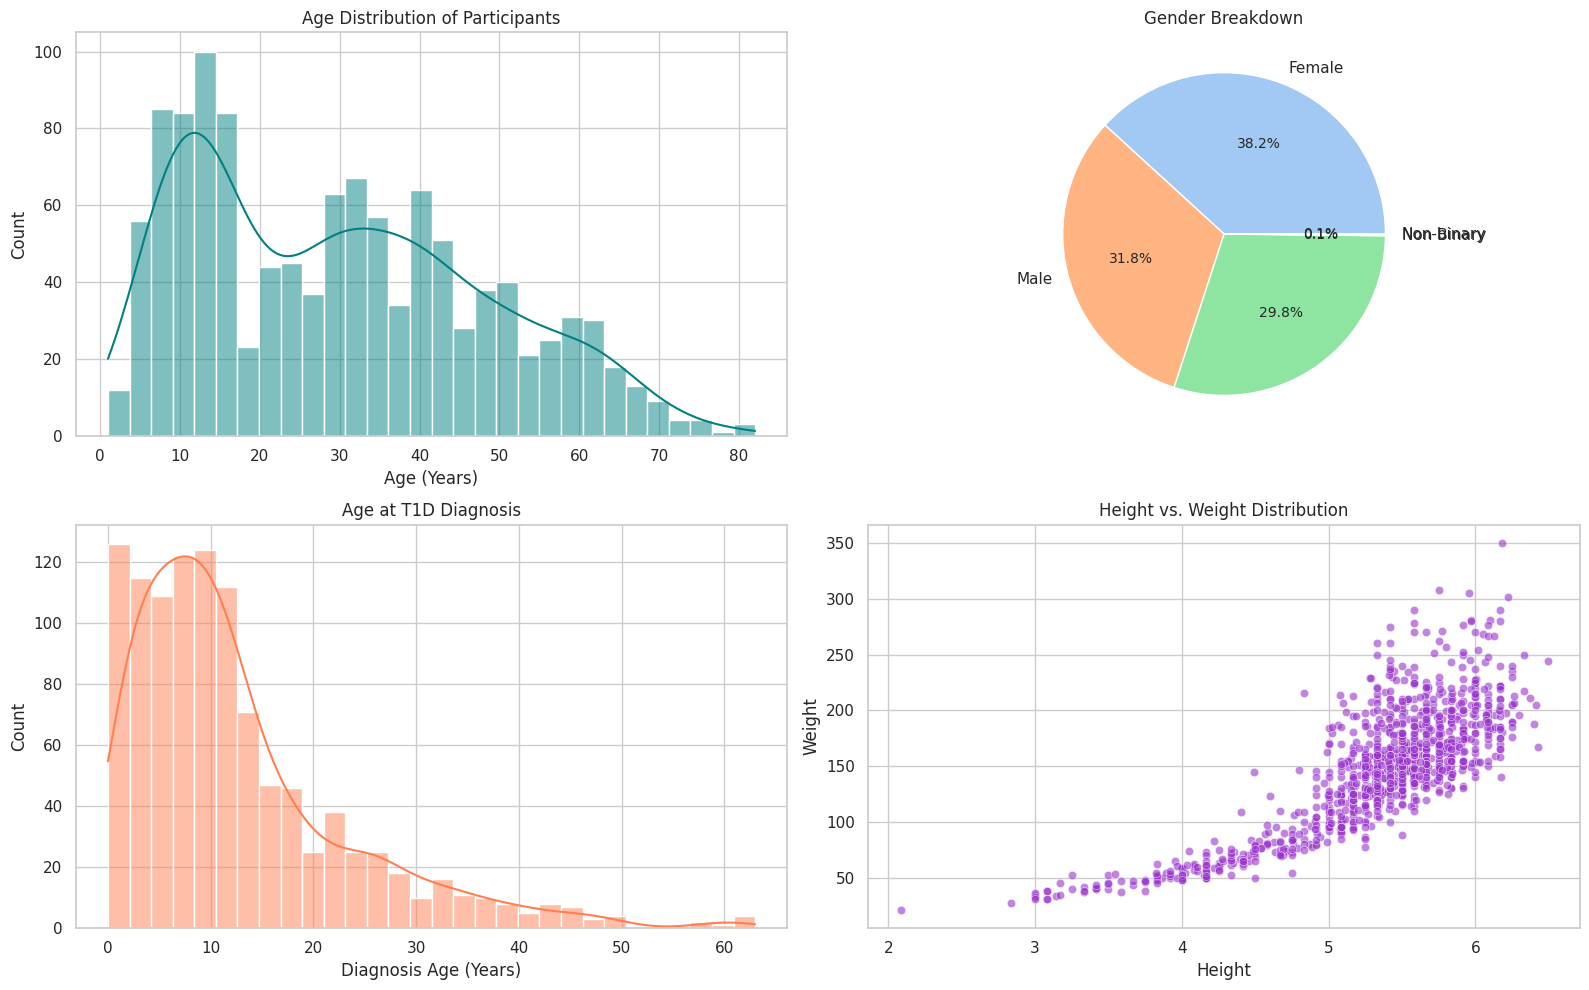

In [4]:
# ==============================================================================
# 4. DEMOGRAPHIC & COHORT DISTRIBUTION ANALYSIS
# ==============================================================================
# In MetaboNet schema, the subject identifier is 'id'
demo_cols = [c for c in ["id", "age", "gender", "ethnicity", "height", "weight", "age_of_diagnosis"] if c in df_train.columns]

if len(demo_cols) > 1:
    df_subjects = df_train.select(demo_cols).unique(subset=["id"]).to_pandas()
    print(f"Total Unique Subjects in Training Set: {len(df_subjects):,}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Age Distribution
    if "age" in df_subjects.columns:
        sns.histplot(df_subjects["age"].dropna(), bins=30, kde=True, ax=axes[0, 0], color="teal")
        axes[0, 0].set_title("Age Distribution of Participants")
        axes[0, 0].set_xlabel("Age (Years)")

    # Gender Distribution
    if "gender" in df_subjects.columns:
        gender_counts = df_subjects["gender"].value_counts(dropna=False)
        axes[0, 1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
        axes[0, 1].set_title("Gender Breakdown")

    # Age of Diagnosis
    if "age_of_diagnosis" in df_subjects.columns:
        sns.histplot(df_subjects["age_of_diagnosis"].dropna(), bins=30, kde=True, ax=axes[1, 0], color="coral")
        axes[1, 0].set_title("Age at T1D Diagnosis")
        axes[1, 0].set_xlabel("Diagnosis Age (Years)")

    # Height vs Weight
    if "height" in df_subjects.columns and "weight" in df_subjects.columns:
        sns.scatterplot(
            data=df_subjects.dropna(subset=["height", "weight"]),
            x="height",
            y="weight",
            alpha=0.6,
            ax=axes[1, 1],
            color="darkorchid"
        )
        axes[1, 1].set_title("Height vs. Weight Distribution")
        axes[1, 1].set_xlabel("Height")
        axes[1, 1].set_ylabel("Weight")

    plt.tight_layout()
    plt.show()

--- Glycemic Control Distribution across Records ---
Time Below Range (<70 mg/dL):          3.22% (Severe <54: 0.62%)
Time in Tight Range (70-140 mg/dL):   50.13%
Time in Target Range (70-180 mg/dL):  72.11%
Time Above Range (>180 mg/dL):        24.66% (Severe >250: 6.80%)
Mean Glucose:                        148.63 mg/dL (SD: 87.27)


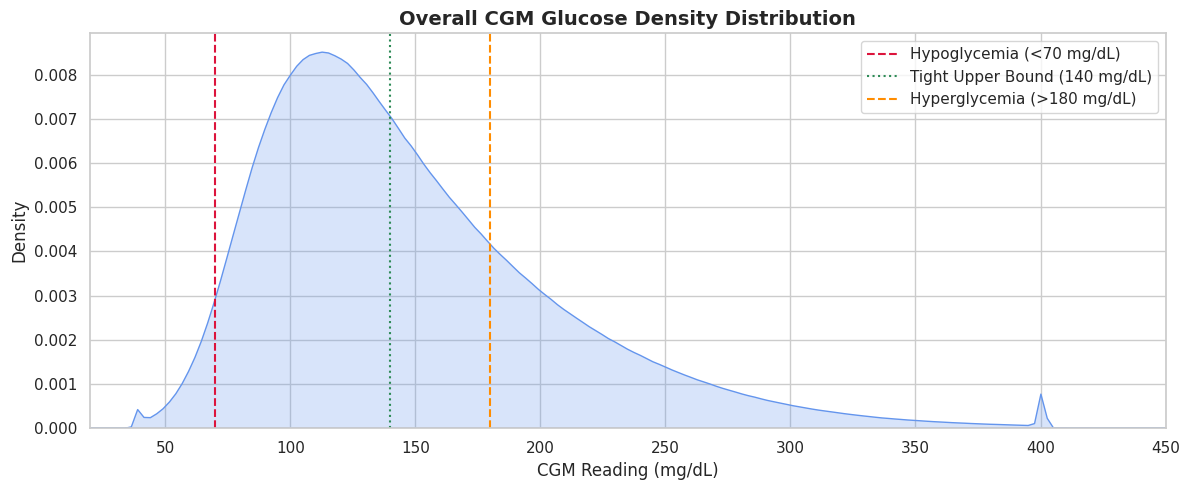

In [5]:
# ==============================================================================
# 5. CLINICAL GLYCEMIC METRICS: TIR, TITR, TBR, TAR
# ==============================================================================
# In MetaboNet schema, the column name is uppercase 'CGM'
if "CGM" in df_train.columns:
    cgm_series = df_train.select("CGM").drop_nulls()["CGM"].to_pandas()
    
    # Calculate Standard Clinical Target Ranges
    tbr_severe = (cgm_series < 54).mean() * 100         # Very low (<54 mg/dL)
    tbr = ((cgm_series >= 54) & (cgm_series < 70)).mean() * 100 # Low (54-69 mg/dL)
    titr = ((cgm_series >= 70) & (cgm_series <= 140)).mean() * 100 # Tight Range (70-140 mg/dL)
    tir = ((cgm_series >= 70) & (cgm_series <= 180)).mean() * 100  # Standard Range (70-180 mg/dL)
    tar = ((cgm_series > 180) & (cgm_series <= 250)).mean() * 100 # High (181-250 mg/dL)
    tar_severe = (cgm_series > 250).mean() * 100        # Very High (>250 mg/dL)

    print("--- Glycemic Control Distribution across Records ---")
    print(f"Time Below Range (<70 mg/dL):        {tbr + tbr_severe:6.2f}% (Severe <54: {tbr_severe:.2f}%)")
    print(f"Time in Tight Range (70-140 mg/dL):  {titr:6.2f}%")
    print(f"Time in Target Range (70-180 mg/dL): {tir:6.2f}%")
    print(f"Time Above Range (>180 mg/dL):       {tar + tar_severe:6.2f}% (Severe >250: {tar_severe:.2f}%)")
    print(f"Mean Glucose:                        {cgm_series.mean():6.2f} mg/dL (SD: {cgm_series.std():.2f})")

    # Plot CGM Density & Thresholds
    plt.figure(figsize=(12, 5))
    sns.kdeplot(cgm_series, fill=True, color="cornflowerblue", bw_adjust=0.8)
    plt.axvline(70, color="crimson", linestyle="--", label="Hypoglycemia (<70 mg/dL)")
    plt.axvline(140, color="seagreen", linestyle=":", label="Tight Upper Bound (140 mg/dL)")
    plt.axvline(180, color="darkorange", linestyle="--", label="Hyperglycemia (>180 mg/dL)")
    plt.title("Overall CGM Glucose Density Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("CGM Reading (mg/dL)")
    plt.ylabel("Density")
    plt.xlim(20, 450)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("CGM column not found in df_train.")

Visualizing longitudinal profile for Subject: 677


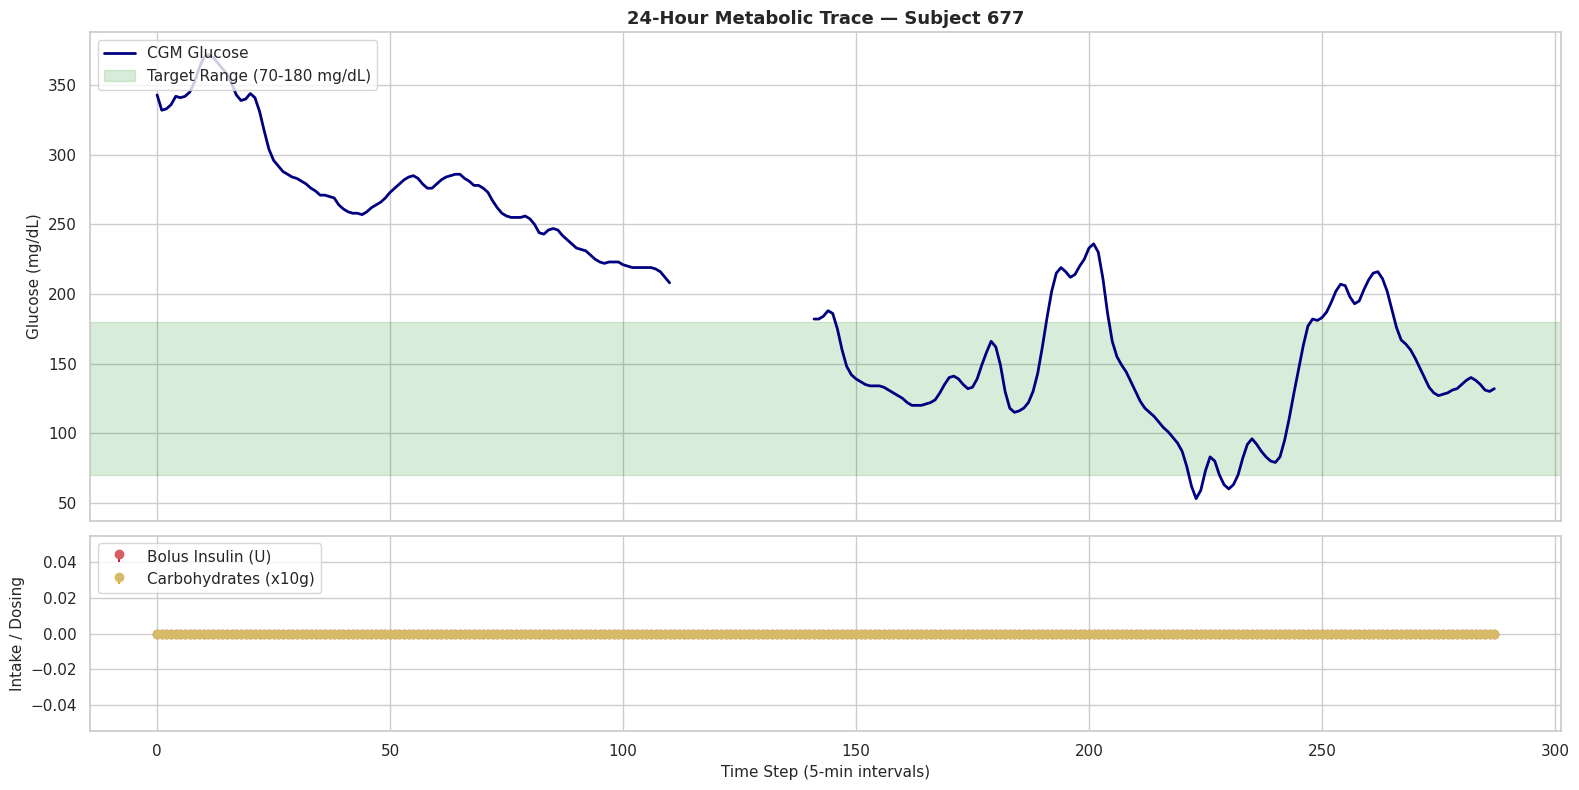

In [6]:
# ==============================================================================
# 6. TIME-SERIES TRAJECTORY VISUALIZATION (SINGLE SUBJECT EXAMPLE)
# ==============================================================================
# In MetaboNet schema, the subject identifier column is 'id' and glucose is 'CGM'
sample_subject = df_train.select("id").drop_nulls().unique()[0, 0]
print(f"Visualizing longitudinal profile for Subject: {sample_subject}")

# Fetch first 288 consecutive steps (approx. 24 hours at 5-minute sampling)
subject_window = (
    df_train.filter(pl.col("id") == sample_subject)
    .head(288)
    .to_pandas()
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={"height_ratios": [2.5, 1]})

# CGM Glucose Profile
if "CGM" in subject_window.columns:
    ax1.plot(subject_window.index, subject_window["CGM"], label="CGM Glucose", color="navy", lw=2)
    ax1.axhspan(70, 180, color="green", alpha=0.15, label="Target Range (70-180 mg/dL)")
    ax1.set_ylabel("Glucose (mg/dL)", fontsize=11)
    ax1.set_title(f"24-Hour Metabolic Trace — Subject {sample_subject}", fontsize=13, fontweight="bold")
    ax1.legend(loc="upper left")

# Insulin & Meal Interventions
if "bolus" in subject_window.columns:
    ax2.stem(
        subject_window.index,
        subject_window["bolus"].fillna(0),
        linefmt="crimson",
        markerfmt="ro",
        basefmt=" ",
        label="Bolus Insulin (U)"
    )
if "carbs" in subject_window.columns:
    ax2.stem(
        subject_window.index,
        subject_window["carbs"].fillna(0) / 10,
        linefmt="orange",
        markerfmt="yo",
        basefmt=" ",
        label="Carbohydrates (x10g)"
    )

ax2.set_ylabel("Intake / Dosing", fontsize=11)
ax2.set_xlabel("Time Step (5-min intervals)", fontsize=11)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()